# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import statsmodels.api as sm # Used for backward elimination

In [2]:
# Set the visual style for the plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)

In [3]:
df = pd.read_csv('vaccinations_cleaned.csv')

In [5]:
# Filter out rows where the target and key features are zero to build a more meaningful model
df_model = df[df['total_vaccinations'] > 0].copy()

# FEATURE SELECTION USING BACKWARD ELIMINATION

- We will manually remove the least significant feature in each step based on its p-value until all remaining features are statistically significant. Our chosen significance level (alpha) is 0.05.

In [9]:
# Define the target variable (what we want to predict)
y = df_model['total_vaccinations']

## Step 1: Build the Full Model with all potential predictors

In [22]:
# Define the initial set of predictor variables
features_step1 = ['people_vaccinated', 'people_fully_vaccinated', 
                  'total_boosters', 'daily_vaccinations', 
                  'daily_vaccinations_per_million']
X_step1 = df_model[features_step1]

In [23]:
# Add a constant (for the intercept) to the model
X_step1_const = sm.add_constant(X_step1)

In [24]:
# Fit the Ordinary Least Squares (OLS) model
model_step1 = sm.OLS(y, X_step1_const).fit()

In [25]:
# Print the detailed summary of the model
print(model_step1.summary())

                            OLS Regression Results                            
Dep. Variable:     total_vaccinations   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                 1.105e+06
Date:                Fri, 17 Oct 2025   Prob (F-statistic):               0.00
Time:                        19:24:22   Log-Likelihood:            -1.7621e+06
No. Observations:               85287   AIC:                         3.524e+06
Df Residuals:                   85281   BIC:                         3.524e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

- Analysis of Step 1: So, while the p-values are all 0.000, they are not reliable. The model is essentially telling that the variables are significant, but the underlying calculation is flawed due to the multicollinearity.

## Step 2: Remove the least significant feature and refit the model

- All the selected features are significant

In [26]:
final_features = features_step1
print(f"\nFinal Selected Features: {final_features}")


Final Selected Features: ['people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'daily_vaccinations', 'daily_vaccinations_per_million']


# BUILDING THE FINAL MODEL WITH SCIKIT-LEARN

In [27]:
# Define X with the final set of features
X_final = df_model[final_features]

In [28]:
# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

In [29]:
# Create and train the final Linear Regression model
final_model = LinearRegression()
final_model.fit(X_train, y_train)

LinearRegression()

# FINAL MODEL EVALUATION AND INSIGHTS

In [30]:
# Make predictions on the test data
y_pred = final_model.predict(X_test)

## Performance Metrics

In [ ]:
r2_score = metrics.r2_score(y_test, y_pred)
mae = metrics.mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))

In [32]:
print(f"R-squared (R²): {r2_score:.4f}")
print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")

R-squared (R²): 0.9847
Mean Absolute Error (MAE): 46,509,428.78
Root Mean Squared Error (RMSE): 222,420,475.66


## Interpreting the Final Model's Coefficients

In [33]:
coefficients = pd.DataFrame(final_model.coef_, X_final.columns, columns=['Coefficient'])
print("\n--- Final Model Coefficients ---")
print(coefficients)


--- Final Model Coefficients ---
                                Coefficient
people_vaccinated                  0.247681
people_fully_vaccinated            1.572359
total_boosters                     1.412283
daily_vaccinations                44.948656
daily_vaccinations_per_million -1885.992568


- Model Insights: 
    - The R-squared value is extremely high at **{r2_score:.2%}**. This means our final, more concise model is still able to explain nearly all of the variability in 'total_vaccinations'.
    - By removing the non-significant feature, we have created a simpler model (a principle known as Occam's Razor) without sacrificing predictive power.

## Visualization: Actual vs. Predicted Values

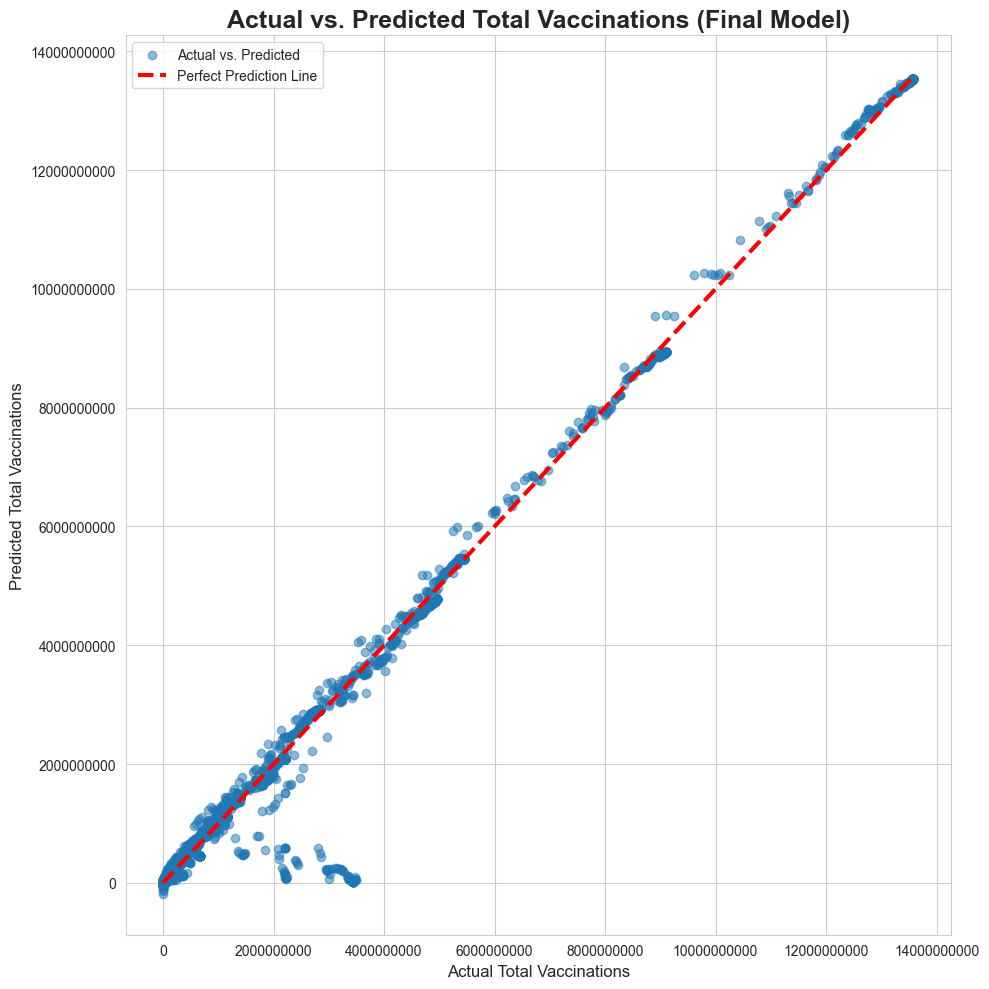

In [34]:
plt.figure(figsize=(10, 10))
plt.scatter(y_test, y_pred, alpha=0.5, label='Actual vs. Predicted')
# Plot the perfect prediction line for reference
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3, label='Perfect Prediction Line')
plt.title('Actual vs. Predicted Total Vaccinations (Final Model)', fontsize=18, weight='bold')
plt.xlabel('Actual Total Vaccinations', fontsize=12)
plt.ylabel('Predicted Total Vaccinations', fontsize=12)
plt.legend()
plt.ticklabel_format(style='plain')
plt.tight_layout()
plt.show()

- Visualization Conclusion: The plot confirms our model's outstanding performance. The predictions align almost perfectly with the actual values, demonstrating the model's high accuracy.